In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
HERE=Path.cwd().resolve()
ANALYSIS=next((p for p in (HERE,*HERE.parents) if (p/'seacofs_tilt_tools.py').exists()),None)
if ANALYSIS is None: raise FileNotFoundError('Launch inside seacofs_eddy_tilt_analysis')
WORK=ANALYSIS/'eddy_env_tilt_controls'
for p in (ANALYSIS,WORK,ANALYSIS/'tilt_mechanisms'):
    if str(p) not in sys.path: sys.path.insert(0,str(p))
import seacofs_tilt_tools as tilt
import control_tools as ctl
import mechanism_tools as mech
N_BOOT=300
MIN_EDDIES_PER_BIN=10
MAX_DEPTH_M=1000
TARGET_DEPTHS=[0,100,200,500,1000]
DEPTH_TOLERANCE_M=65
MIN_N2_COVERAGE=.8
SAVE_RESULTS=True
paths=tilt.Paths()
OUTPUT_ROOT=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/eddy_env_tilt_controls')
N2_CACHE=mech.DEFAULT_N2_CACHE_PATH
VV_CACHE=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/vertical_velocity_climatology/core_vertical_velocity_upper_1000m.parquet')
VV_FRACTION=1.5
MIN_VV_CELLS=8
MIN_VV_COVERAGE=.7
results={}
inputs=[paths.eddies,paths.tilt,paths.vert,paths.grid,paths.z_r,WORK/'control_tools.py']

In [2]:
grid=tilt.load_grid(paths.grid,paths.z_r)
raw,_=tilt.load_tilt_tables(paths,add_regions=True,grid=grid)
surface=ctl.prepare_surface(raw,grid)
# vertical=ctl.prepare_profiles(tilt.load_vert(paths),surface,MAX_DEPTH_M)


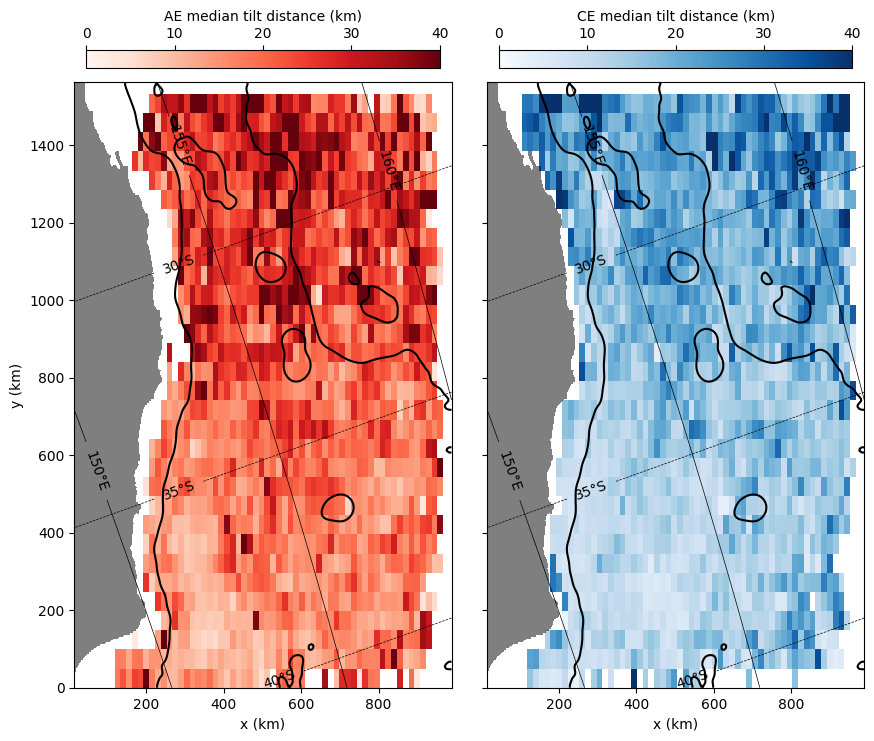

In [3]:
fig, axs = tilt.plot_binned_median_map(surface, grid, clabel_var='tilt distance',
                                       metric='TiltDis', vmin=0, vmax=40)

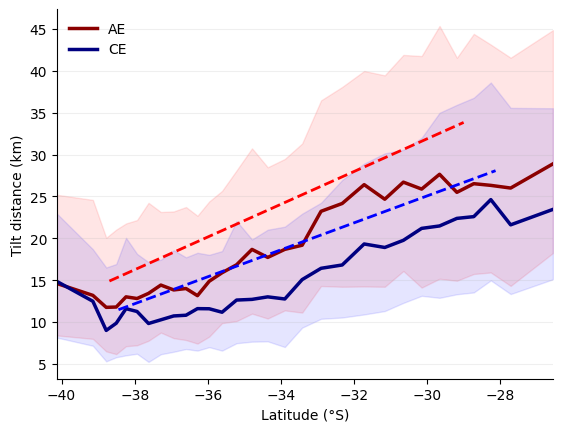

In [4]:
fig, ax = plt.subplots()
tilt.binned_tilt_panel(ax, surface, 'lat', 'Latitude (°S)',
                       xlim=(grid.lat_rho.min(),grid.lat_rho.max()), linfit=True)
ax.set_ylabel("Tilt distance (km)")
ax.legend(frameon=False)
plt.show()

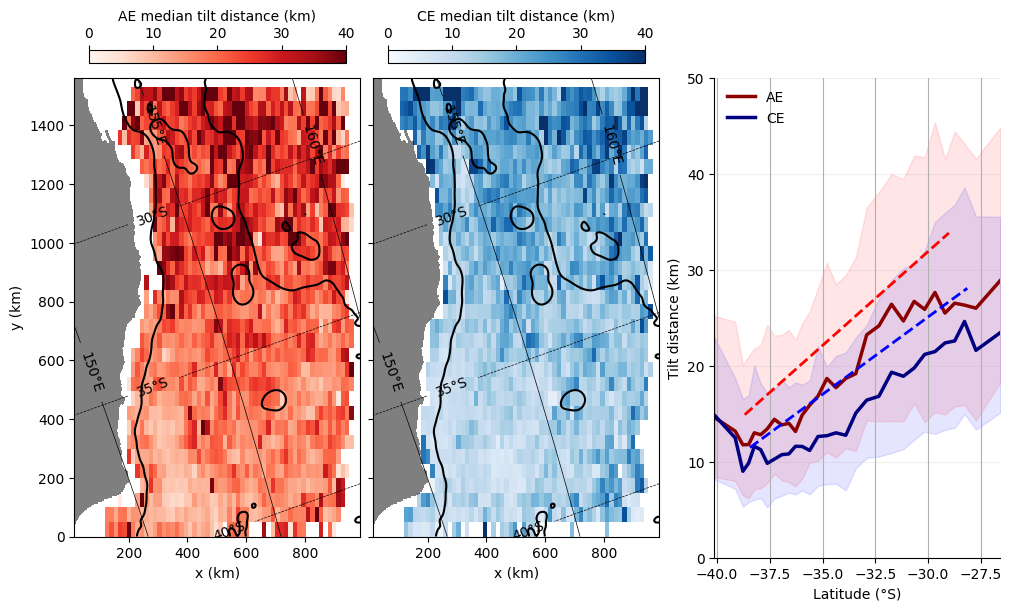

In [5]:
fig, axs = plt.subplots(
    1, 3, figsize=(10, 6),
    constrained_layout=True
)

tilt.plot_binned_median_map(
    surface, grid,
    clabel_var='tilt distance',
    metric='TiltDis',
    vmin=0, vmax=40,
    fig=fig,
    axs=axs[:2],
    show=False
)
axs[1].set_yticklabels([])

tilt.binned_tilt_panel(
    axs[2], surface,
    'lat', 'Latitude (°S)',
    xlim=(-40, -26), #(grid.lat_rho.min(), grid.lat_rho.max()),
    linfit=True,
    bin_xlim=True
)
axs[2].set_ylim(0,50); axs[2].grid(True)
# axs[2].set_xticks(np.arange(-40, -26 + 3,3))

axs[2].set_ylabel('Tilt distance (km)')
axs[2].legend(frameon=False)

# for ax,l in zip(axs,['a)','b)','c)']):
#     ax.text(-.15 if l!='c)' else -.2,1.01,l,transform=ax.transAxes,ha='left',va='top',
#             fontsize=12,fontweight='bold')

plt.show()